<a href="https://colab.research.google.com/github/KokYong-Tan/SMU-MDSE/blob/main/week1_computing_colab_Tan_Kok_Yong.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DS603 Week 1 Lab — Sets, Counting, and Computations

**Assigned readings (Course Outline, Week 1)**
- **IPDS** 1.5 Basic Combinatorics; **IPDS** 2.1 Set Theory
- **MPQE** 2.1 Math/functions; **MPQE** 3.2 Elementary set theory; **MPQE** 3.4 Python

**Lab order**
1. Python as a calculator (MPQE 3.4)
2. Set computations and Venn diagrams (IPDS 2.1, MPQE 3.4.4)
3. Counting: Cartesian products, (n,k)$, (n,k)$ (IPDS 1.5, MPQE 3.2)

Optional: !pip install -q matplotlib-venn


## 1. Python as a calculator (MPQE 3.4)

In [ ]:
import math  # math library: sqrt, perm, comb, etc.
from itertools import product, combinations, permutations  # tools for listing products / selections

print(2 + 3 * 4)  # * before +; result is 14
print(2 ** 10)  # ** means exponentiation; 2^10 = 1024
print('sqrt(2) =', math.sqrt(2))  # square root of 2 via math.sqrt
# IPDS Theorems 1.6 and 1.7
print('P(10,3) =', math.perm(10, 3), '  # n!/(n-k)!')  # ordered selections of 3 from 10
print('C(10,3) =', math.comb(10, 3), '  # n!/(k!(n-k)!)')  # unordered selections of 3 from 10


14
1024
sqrt(2) = 1.4142135623730951
P(10,3) = 720   # n!/(n-k)!
C(10,3) = 120   # n!/(k!(n-k)!)


## 2. Set computations (IPDS 2.1 / MPQE 3.4) Use a universal set Omega as in IPDS.

In [ ]:
A = {1, 2, 3, 4}  # set A (Python uses curly braces for sets)
B = {3, 4, 5}  # set B; shares 3 and 4 with A
Omega = {1, 2, 3, 4, 5, 6}  # universal set Omega (like a six-sided die)
print('A =', A)  # display set A used in Part 2
print('B =', B)  # display set B used in Part 2
print('Omega =', Omega)  # display the universal set

print('union        A|B =', A | B)  # | is union: elements in A or B (or both)
print('intersection A&B =', A & B)  # & is intersection: elements in both A and B
print('difference   A-B =', A - B)  # - is difference: in A but not in B
print('complement Omega-A =', Omega - A)  # complement of A relative to Omega
print('subset A<=Omega?', A <= Omega)  # <= tests subset: every element of A is in Omega

# IPDS Thm 2.5 De Morgan
left = Omega - (A | B)  # left side of De Morgan: (A ∪ B)^c, c is complement
right = (Omega - A) & (Omega - B)  # right side: A^c ∩ B^c
print('De Morgan holds?', left == right, '->', left)  # check the two sides agree

# MPQE 3.2 Cartesian example
print('MPQE A×B =', set(product({1,2,3}, {3,4})))  # all ordered pairs (a,b); wrap in set for display


A = {1, 2, 3, 4}
B = {3, 4, 5}
Omega = {1, 2, 3, 4, 5, 6}
union        A|B = {1, 2, 3, 4, 5}
intersection A&B = {3, 4}
difference   A-B = {1, 2}
complement Omega-A = {5, 6}
subset A<=Omega? True
De Morgan holds? True -> {6}
MPQE A×B = {(2, 4), (3, 4), (1, 4), (2, 3), (3, 3), (1, 3)}


### Venn diagrams (IPDS 2.1 style)

Venn diagrams use the Part 2 sets:
  A = {1, 2, 3, 4}
  B = {3, 4, 5}
  Omega = {1, 2, 3, 4, 5, 6}


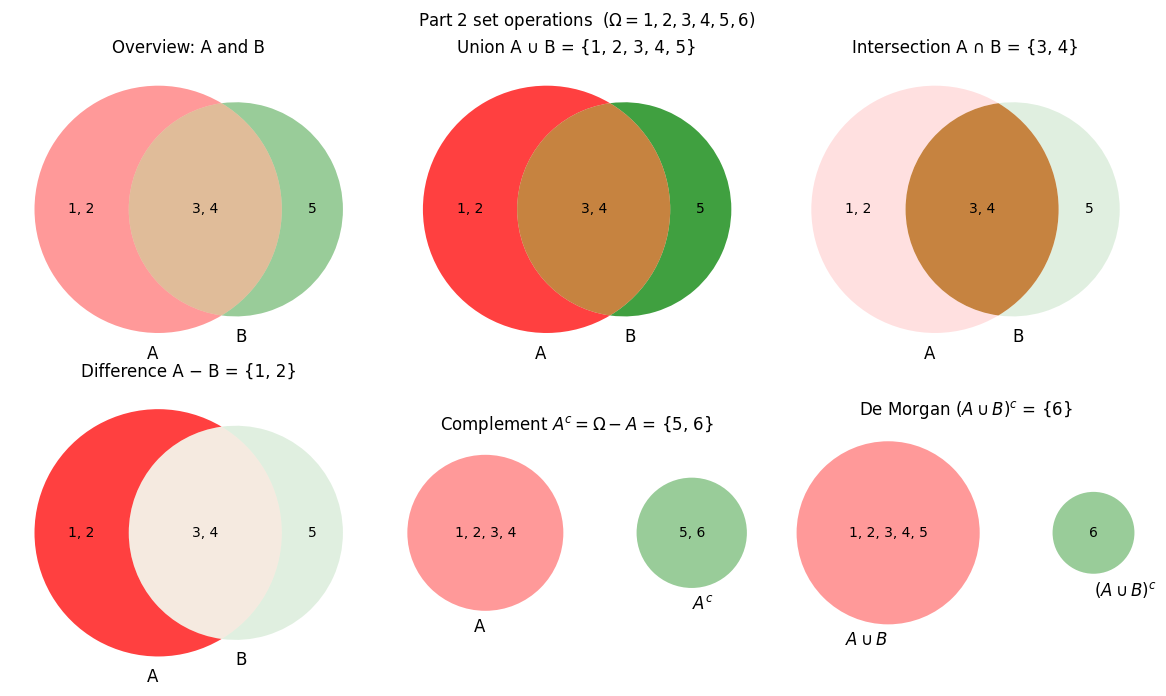

In [ ]:
# !pip install -q matplotlib-venn  # uncomment once if matplotlib-venn is not installed
from matplotlib_venn import venn2  # two-set Venn diagram helper
import matplotlib.pyplot as plt  # pyplot interface for figures

# Same sets as in the Part 2 computations above (redefined here so the plots stay correct
# even if a later cell overwrote A / B / Omega)
A = {1, 2, 3, 4}  # set A from Part 2
B = {3, 4, 5}  # set B from Part 2
Omega = {1, 2, 3, 4, 5, 6}  # universal set from Part 2
print('Venn diagrams use the Part 2 sets:')  # confirm which sets are plotted
print('  A =', A)  # should match the set-computation cell
print('  B =', B)
print('  Omega =', Omega)

def fmt_set(S):  # pretty-print a set for region labels
    if not S:  # empty region
        return '∅'  # empty-set symbol
    return ', '.join(str(x) for x in sorted(S))  # sorted elements as text

def label_ab_regions(v, A, B):  # replace counts with actual elements
    mapping = {'10': A - B, '01': B - A, '11': A & B}  # region id -> elements
    for pid, elems in mapping.items():  # walk each region
        lab = v.get_label_by_id(pid)  # text object (or None)
        if lab is not None:  # region is drawn
            lab.set_text(fmt_set(elems))  # show elements, not a count

def shade_regions(v, highlight):  # highlight chosen region ids
    for pid in ('10', '01', '11'):  # all two-set regions
        patch = v.get_patch_by_id(pid)  # patch for that region
        if patch is not None:  # skip missing regions
            patch.set_alpha(0.75 if pid in highlight else 0.12)  # bright vs dim

Ac = Omega - A  # complement of A relative to Omega
union_AB = A | B  # A ∪ B
demorgan = Omega - union_AB  # (A ∪ B)^c

fig, axes = plt.subplots(2, 3, figsize=(12, 7))  # 2×3 panel grid
axes = axes.ravel()  # flatten to a list of axes

# Overview: A and B with element labels
plt.sca(axes[0])  # select first panel
v0 = venn2((A, B), set_labels=('A', 'B'))  # draw A and B
label_ab_regions(v0, A, B)  # show elements in each region
axes[0].set_title('Overview: A and B')  # panel title

# Union A ∪ B
plt.sca(axes[1])
v1 = venn2((A, B), set_labels=('A', 'B'))
label_ab_regions(v1, A, B)
shade_regions(v1, {'10', '01', '11'})  # shade all of the union
axes[1].set_title(f'Union A ∪ B = {{{fmt_set(union_AB)}}}')

# Intersection A ∩ B
plt.sca(axes[2])
v2 = venn2((A, B), set_labels=('A', 'B'))
label_ab_regions(v2, A, B)
shade_regions(v2, {'11'})  # shade the middle only
axes[2].set_title(f'Intersection A ∩ B = {{{fmt_set(A & B)}}}')

# Difference A − B
plt.sca(axes[3])
v3 = venn2((A, B), set_labels=('A', 'B'))
label_ab_regions(v3, A, B)
shade_regions(v3, {'10'})  # shade A-only
axes[3].set_title(f'Difference A − B = {{{fmt_set(A - B)}}}')

# Complement A^c = Ω − A
plt.sca(axes[4])
v4 = venn2((A, Ac), set_labels=('A', r'$A^c$'))  # A vs its complement
if v4.get_label_by_id('10') is not None:
    v4.get_label_by_id('10').set_text(fmt_set(A))  # elements of A
if v4.get_label_by_id('01') is not None:
    v4.get_label_by_id('01').set_text(fmt_set(Ac))  # elements of A^c
axes[4].set_title(f'Complement $A^c=\\Omega-A$ = {{{fmt_set(Ac)}}}')

# De Morgan (A ∪ B)^c
plt.sca(axes[5])
v5 = venn2((union_AB, demorgan), set_labels=(r'$A\cup B$', r'$(A\cup B)^c$'))
if v5.get_label_by_id('10') is not None:
    v5.get_label_by_id('10').set_text(fmt_set(union_AB))  # elements of the union
if v5.get_label_by_id('01') is not None:
    v5.get_label_by_id('01').set_text(fmt_set(demorgan))  # outside the union
axes[5].set_title(f'De Morgan $(A\\cup B)^c$ = {{{fmt_set(demorgan)}}}')

fig.suptitle(rf'Part 2 set operations  ($\Omega={{{fmt_set(Omega)}}}$)', fontsize=12)
plt.tight_layout()  # reduce wasted whitespace
plt.show()  # display all six panels in the notebook


### Ratings partition of Omega

In [ ]:
Omega_r = {'AAA', 'AA', 'A', 'BBB', 'BB', 'B'}  # rating grades as the universal set
IG = {'AAA', 'AA', 'A', 'BBB'}  # investment-grade ratings
Spec = Omega_r - IG  # speculative = complement of IG in Omega_r
print('disjoint?', IG & Spec == set())  # non-overlap: intersection should be empty
print('cover Omega?', IG | Spec == Omega_r)  # decompose: union should equal Omega_r


disjoint? True
cover Omega? True


## 3. Counting (IPDS 1.5 / MPQE 3.2)

### Cartesian products

In [ ]:
grades = ['IG', 'HY']  # two credit grades
sectors = ['Energy', 'Tech', 'Banks']  # three sectors
omega = list(product(grades, sectors))  # all ordered pairs (grade, sector); |Ω|=2*3
print('|Ω| =', len(omega))  # cardinality of the two-factor product (expect 6)
regions = ['APAC', 'EMEA', 'AMER']  # three geographic regions
print('|grades×sectors×regions| =', len(list(product(grades, sectors, regions))))  # three-factor product; expect 18


|Ω| = 6
|grades×sectors×regions| = 18


### Permutations and combinations (IPDS 1.5.2–1.5.3)

In [ ]:
assets = [f'A{i}' for i in range(1, 11)]  # labels A1,...,A10 (list comprehension)
print('P(10,3) =', math.perm(10, 3))  # number of ordered triples from 10 assets
print('C(10,3) =', math.comb(10, 3))  # number of unordered triples (portfolios)
print('list sizes', len(list(permutations(assets, 3))), len(list(combinations(assets, 3))))  # check listed lengths match P and C


P(10,3) = 720
C(10,3) = 120
list sizes 720 120


### With / without replacement + birthday sketch (IPDS 1.5.1)

In [ ]:
print('with replacement 2**4 =', len(list(product(['U','D'], repeat=4))))  # 4-step U/D paths with replacement; expect 16
print('P(3,2) =', math.perm(3, 2), list(permutations(sectors, 2)))  # ordered pairs of distinct sectors; P(3,2)=6
print('C(3,2) =', math.comb(3, 2), list(combinations(sectors, 2)))  # unordered pairs of distinct sectors; C(3,2)=3

def prob_shared_birthday(k, days=365):  # approx P(at least two people share a birthday)
    return 1 - math.perm(days, k) / (days ** k)  # 1 minus P(all birthdays distinct)

for k in (10, 23, 40):  # try three group sizes
    print(f'k={k}: P(shared) ≈ {prob_shared_birthday(k):.3f}')  # print probability to 3 decimals


with replacement 2**4 = 16
P(3,2) = 6 [('Energy', 'Tech'), ('Energy', 'Banks'), ('Tech', 'Energy'), ('Tech', 'Banks'), ('Banks', 'Energy'), ('Banks', 'Tech')]
C(3,2) = 3 [('Energy', 'Tech'), ('Energy', 'Banks'), ('Tech', 'Banks')]
k=10: P(shared) ≈ 0.117
k=23: P(shared) ≈ 0.507
k=40: P(shared) ≈ 0.891


## Exercises
**E1.** (IPDS 2.1) On Omega ={1,....,10}, Let A = evens and B = multiple of 3. Verify both De Morgan laws.

In [1]:
Omega = set(range(1, 11))  # universal set {1,2,...,10}
A = {x for x in Omega if x % 2 == 0}  # evens in Omega (set comprehension)
B = {x for x in Omega if x % 3 == 0}  # multiples of 3 in Omega
print('A=', A); print('B=', B)  # display A and B
# TODO: both De Morgan identities: check (A∪B)^c and (A∩B)^c

# Complements
Ac = Omega - A
Bc = Omega - B

# De Morgan Law 1
left1 = Omega - (A | B)
right1 = Ac & Bc

# De Morgan Law 2
left2 = Omega - (A & B)
right2 = Ac | Bc

# Display results
print("Omega =", Omega)
print("A =", A)
print("B =", B)
print("A complement =", Ac)
print("B complement =", Bc)

print("\nDe Morgan Law 1:")
print("(A union B)^c =", left1)
print("A^c intersection B^c =", right1)
print("Verified:", left1 == right1)

print("\nDe Morgan Law 2:")
print("(A intersection B)^c =", left2)
print("A^c union B^c =", right2)
print("Verified:", left2 == right2)

A= {2, 4, 6, 8, 10}
B= {9, 3, 6}
Omega = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10}
A = {2, 4, 6, 8, 10}
B = {9, 3, 6}
A complement = {1, 3, 5, 7, 9}
B complement = {1, 2, 4, 5, 7, 8, 10}

De Morgan Law 1:
(A union B)^c = {1, 5, 7}
A^c intersection B^c = {1, 5, 7}
Verified: True

De Morgan Law 2:
(A intersection B)^c = {1, 2, 3, 4, 5, 7, 8, 9, 10}
A^c union B^c = {1, 2, 3, 4, 5, 7, 8, 9, 10}
Verified: True


## Exercises
**E2.** (IPDS 1.5) C(12,4) and P(12,4).


In [ ]:
print('C(12,4)=', math.comb(12, 4), ' P(12,4)=', math.perm(12, 4))  # unordered vs ordered selections of 4 from 12

C(12,4)= 495  P(12,4)= 11880


## Exercises
**E3.** (MPQE 3.2) product for 2×4×3 rating/sector/region; report |Omega|.



In [ ]:
Omega4 = list(product(['IG','HY'],  # 2 ratings
                      ['Energy','Tech','Banks','Utilities'],  # 4 sectors
                      ['APAC','EMEA','AMER']))  # 3 regions; full product sample space
print('Omega =')
for outcome in Omega4:
    print (outcome)
print('|Omega|=', len(Omega4))  # expect 2*4*3 = 24


Omega =
('IG', 'Energy', 'APAC')
('IG', 'Energy', 'EMEA')
('IG', 'Energy', 'AMER')
('IG', 'Tech', 'APAC')
('IG', 'Tech', 'EMEA')
('IG', 'Tech', 'AMER')
('IG', 'Banks', 'APAC')
('IG', 'Banks', 'EMEA')
('IG', 'Banks', 'AMER')
('IG', 'Utilities', 'APAC')
('IG', 'Utilities', 'EMEA')
('IG', 'Utilities', 'AMER')
('HY', 'Energy', 'APAC')
('HY', 'Energy', 'EMEA')
('HY', 'Energy', 'AMER')
('HY', 'Tech', 'APAC')
('HY', 'Tech', 'EMEA')
('HY', 'Tech', 'AMER')
('HY', 'Banks', 'APAC')
('HY', 'Banks', 'EMEA')
('HY', 'Banks', 'AMER')
('HY', 'Utilities', 'APAC')
('HY', 'Utilities', 'EMEA')
('HY', 'Utilities', 'AMER')
|Omega|= 24
